# Лабораторная работа: Линейные модели, SVM и деревья решений

**Датасет:** Tea vs Coffee Global (`tea_vs_coffee_global_final.csv`)

**Задача:** Бинарная классификация — предсказание предпочтения напитка (`drink_preference`: Tea или Coffee)

## Цель
- Подготовить данные: заполнить пропуски и закодировать категориальные признаки
- Разделить выборку на обучающую и тестовую (`train_test_split`)
- Обучить: логистическую регрессию, SVM, дерево решений
- Оценить качество моделей по двум метрикам (Accuracy, F1-score)
- Построить график важности признаков дерева решений
- Визуализировать дерево решений

## 1. Загрузка библиотек и данных

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_csv('tea_vs_coffee_global_final.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (15000, 34)


,country,continent,year,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
0,Bangladesh,Asia,2015,56,Male,Low,Coffee,Mocha,Modern,2.3,...,Moderate,26.9,9,86,Taste,Work,Afternoon,Explorer,No,3
1,Bangladesh,Asia,2015,61,Other,High,Tea,Oolong Tea,Traditional,1.3,...,High,20.9,1,95,Habit,Family,Night,Explorer,No,6
2,Bangladesh,Asia,2015,59,Female,Low,Coffee,Americano,Modern,3.2,...,Low,31.6,1,84,Taste,Alone,Night,Brand Loyal,No,8
3,Bangladesh,Asia,2015,41,Other,High,Coffee,Cappuccino,Modern,3.0,...,Moderate,33.1,1,94,Energy,Work,Afternoon,Brand Loyal,Yes,5
4,Bangladesh,Asia,2015,43,Other,Middle,Tea,Green Tea,Traditional,1.9,...,High,29.8,2,65,Social,Family,Night,Explorer,No,7


## 2. Первичный анализ данных (EDA)

In [3]:
print('=== Типы данных ===')
print(df.dtypes)
print(f'\n=== Пропуски ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Пропуски отсутствуют')

=== Типы данных ===
country                      str
continent                    str
year                       int64
age                        int64
gender                       str
income_level                 str
drink_preference             str
favorite_drink               str
drink_category               str
cups_per_day             float64
drink_temperature            str
sugar_level                  str
milk_usage                   str
caffeine_preference          str
taste_score              float64
bitterness               float64
acidity                  float64
aroma_score              float64
monthly_spend            float64
price_per_cup            float64
home_vs_cafe_ratio       float64
work_type                    str
sleep_hours              float64
stress_level               int64
exercise_frequency           str
bmi                      float64
hydration_level            int64
heart_rate                 int64
drink_reason                 str
social_setting         

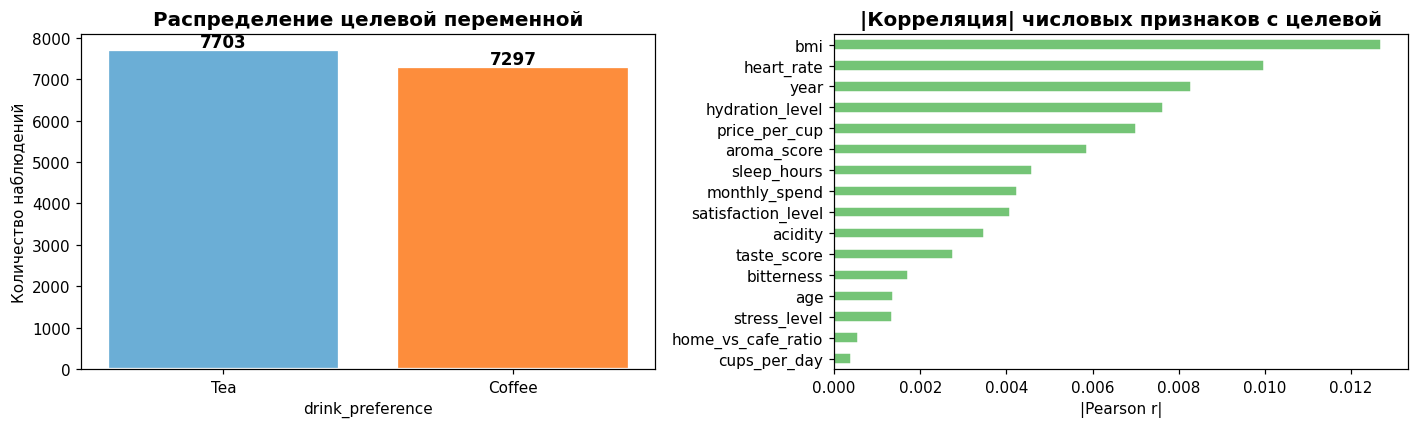

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Распределение целевой переменной
counts = df['drink_preference'].value_counts()
colors = ['#6baed6', '#fd8d3c']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Распределение целевой переменной', fontsize=13, fontweight='bold')
axes[0].set_xlabel('drink_preference')
axes[0].set_ylabel('Количество наблюдений')
for i, (cat, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 80, str(cnt), ha='center', fontsize=11, fontweight='bold')

# Числовые признаки — корреляция с целевой переменной
df_num = df.select_dtypes(include='number')
target_enc = (df['drink_preference'] == 'Coffee').astype(int)
corr_vals = df_num.corrwith(target_enc).abs().sort_values(ascending=True)
corr_vals.plot(kind='barh', ax=axes[1], color='#74c476', edgecolor='white')
axes[1].set_title('|Корреляция| числовых признаков с целевой', fontsize=13, fontweight='bold')
axes[1].set_xlabel('|Pearson r|')

plt.tight_layout()
plt.show()

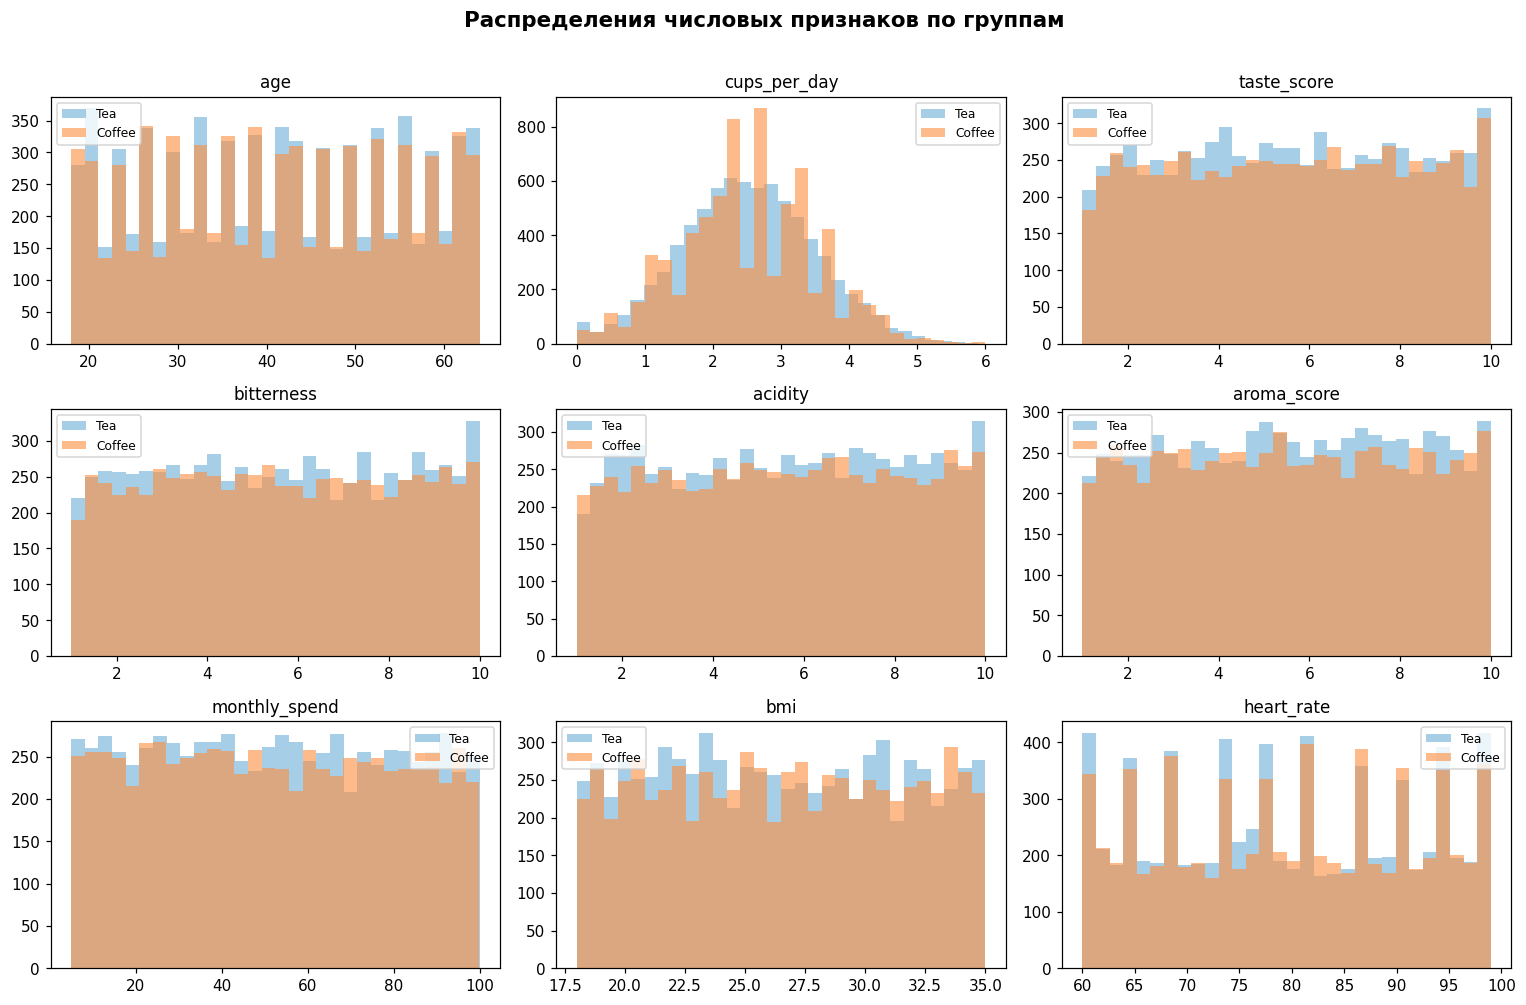

In [5]:
num_cols = ['age', 'cups_per_day', 'taste_score', 'bitterness',
            'acidity', 'aroma_score', 'monthly_spend', 'bmi', 'heart_rate']

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()
palette = {'Tea': '#6baed6', 'Coffee': '#fd8d3c'}

for i, col in enumerate(num_cols):
    for label, color in palette.items():
        subset = df[df['drink_preference'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

fig.suptitle('Распределения числовых признаков по группам', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Предобработка данных

In [6]:
# Удаляем признаки, которые напрямую идентифицируют категорию или дублируют цель
drop_cols = ['favorite_drink', 'drink_category']
df_clean = df.drop(columns=drop_cols).copy()

# Целевая переменная
y = (df_clean['drink_preference'] == 'Coffee').astype(int)  # Coffee=1, Tea=0
df_clean = df_clean.drop(columns=['drink_preference'])

# Заполнение пропусков (если есть)
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Label Encoding категориальных признаков
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print(f'Признаков после предобработки: {df_clean.shape[1]}')
print(f'Целевая переменная — Coffee: {y.sum()}, Tea: {(y==0).sum()}')
df_clean.head(3)

Признаков после предобработки: 31
Целевая переменная — Coffee: 7297, Tea: 7703


,country,continent,year,age,gender,income_level,cups_per_day,drink_temperature,sugar_level,milk_usage,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
0,1,2,2015,56,1,1,2.3,0,2,0,...,2,26.9,9,86,3,3,0,1,0,3
1,1,2,2015,61,2,0,1.3,0,1,0,...,0,20.9,1,95,1,1,3,1,0,6
2,1,2,2015,59,0,1,3.2,1,2,0,...,1,31.6,1,84,3,0,3,0,0,8


## 4. Разделение на обучающую и тестовую выборки

In [7]:
X = df_clean.values
feature_names = df_clean.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирование (для логрег и SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Доля Coffee в train: {y_train.mean():.3f} | в test: {y_test.mean():.3f}')

Train: 12000 samples | Test: 3000 samples
Доля Coffee в train: 0.486 | в test: 0.486


## 5. Обучение моделей

### 5.1 Логистическая регрессия (линейная модель)

In [8]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_sc, y_train)

y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)

print('=== Логистическая регрессия ===')
print(f'Accuracy : {acc_lr:.4f}')
print(f'F1-score : {f1_lr:.4f}')
print(f'ROC-AUC  : {roc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Tea', 'Coffee']))

=== Логистическая регрессия ===
Accuracy : 0.5047
F1-score : 0.3550
ROC-AUC  : 0.5012

              precision    recall  f1-score   support

         Tea       0.51      0.72      0.60      1541
      Coffee       0.48      0.28      0.36      1459

    accuracy                           0.50      3000
   macro avg       0.50      0.50      0.48      3000
weighted avg       0.50      0.50      0.48      3000



### 5.2 SVM (метод опорных векторов)

In [9]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

y_pred_svm = svm.predict(X_test_sc)
y_prob_svm = svm.predict_proba(X_test_sc)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm)
roc_svm = roc_auc_score(y_test, y_prob_svm)

print('=== SVM (RBF kernel) ===')
print(f'Accuracy : {acc_svm:.4f}')
print(f'F1-score : {f1_svm:.4f}')
print(f'ROC-AUC  : {roc_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['Tea', 'Coffee']))

=== SVM (RBF kernel) ===
Accuracy : 0.5300
F1-score : 0.4865
ROC-AUC  : 0.5314

              precision    recall  f1-score   support

         Tea       0.54      0.60      0.57      1541
      Coffee       0.52      0.46      0.49      1459

    accuracy                           0.53      3000
   macro avg       0.53      0.53      0.53      3000
weighted avg       0.53      0.53      0.53      3000



### 5.3 Дерево решений

In [10]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)  # деревья не требуют масштабирования

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)
roc_dt = roc_auc_score(y_test, y_prob_dt)

print('=== Дерево решений (max_depth=5) ===')
print(f'Accuracy : {acc_dt:.4f}')
print(f'F1-score : {f1_dt:.4f}')
print(f'ROC-AUC  : {roc_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['Tea', 'Coffee']))

=== Дерево решений (max_depth=5) ===
Accuracy : 0.5693
F1-score : 0.6056
ROC-AUC  : 0.5766

              precision    recall  f1-score   support

         Tea       0.61      0.46      0.53      1541
      Coffee       0.55      0.68      0.61      1459

    accuracy                           0.57      3000
   macro avg       0.58      0.57      0.57      3000
weighted avg       0.58      0.57      0.56      3000



## 6. Сравнение качества моделей

In [11]:
results = pd.DataFrame({
    'Модель'   : ['Логистическая регрессия', 'SVM (RBF)', 'Дерево решений'],
    'Accuracy' : [acc_lr, acc_svm, acc_dt],
    'F1-score' : [f1_lr,  f1_svm,  f1_dt],
    'ROC-AUC'  : [roc_lr, roc_svm, roc_dt],
})
results = results.set_index('Модель')
results.style.highlight_max(axis=0, color='#c7e9c0').format('{:.4f}')

,Accuracy,F1-score,ROC-AUC
Модель,,,
Логистическая регрессия,0.5047,0.3550,0.5012
SVM (RBF),0.5300,0.4865,0.5314
Дерево решений,0.5693,0.6056,0.5766


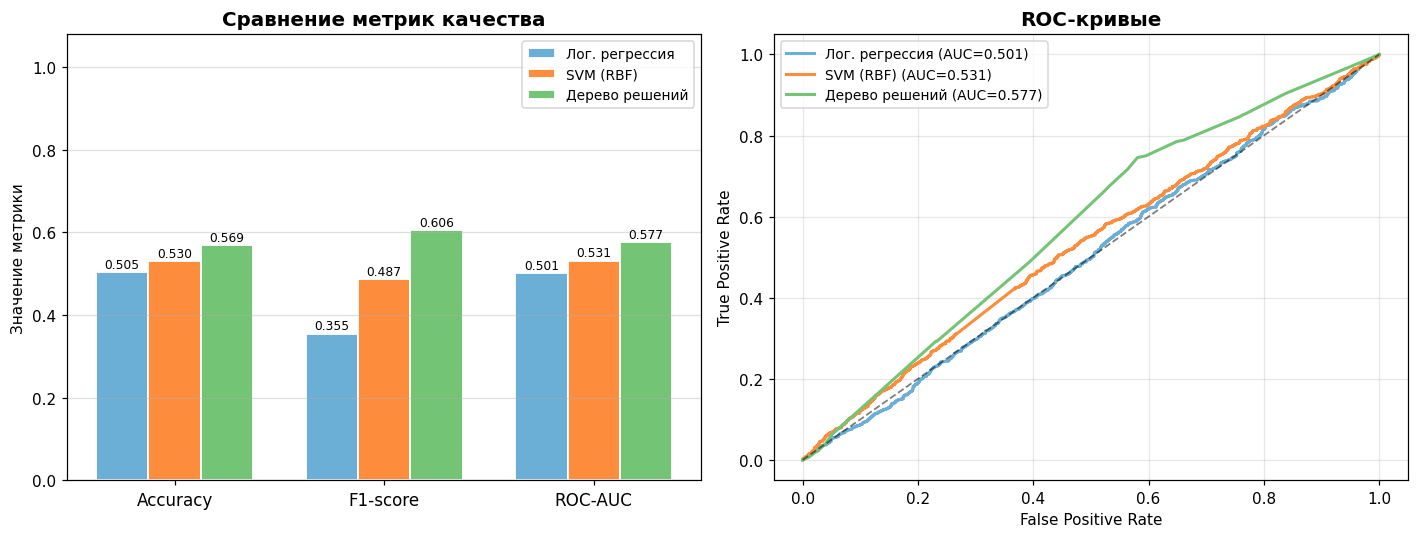

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Гистограмма метрик ---
metrics = ['Accuracy', 'F1-score', 'ROC-AUC']
models  = ['Лог. регрессия', 'SVM (RBF)', 'Дерево решений']
values  = [
    [acc_lr,  f1_lr,  roc_lr],
    [acc_svm, f1_svm, roc_svm],
    [acc_dt,  f1_dt,  roc_dt],
]
bar_colors = ['#6baed6', '#fd8d3c', '#74c476']
x = np.arange(len(metrics))
width = 0.25

for i, (model, vals, color) in enumerate(zip(models, values, bar_colors)):
    bars = axes[0].bar(x + i * width, vals, width, label=model,
                        color=color, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, fontsize=11)
axes[0].set_ylim(0, 1.08)
axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Сравнение метрик качества', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)

# --- ROC-кривые ---
for (name, y_prob, color) in [
    ('Лог. регрессия', y_prob_lr,  '#6baed6'),
    ('SVM (RBF)',       y_prob_svm, '#fd8d3c'),
    ('Дерево решений',  y_prob_dt,  '#74c476'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривые', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

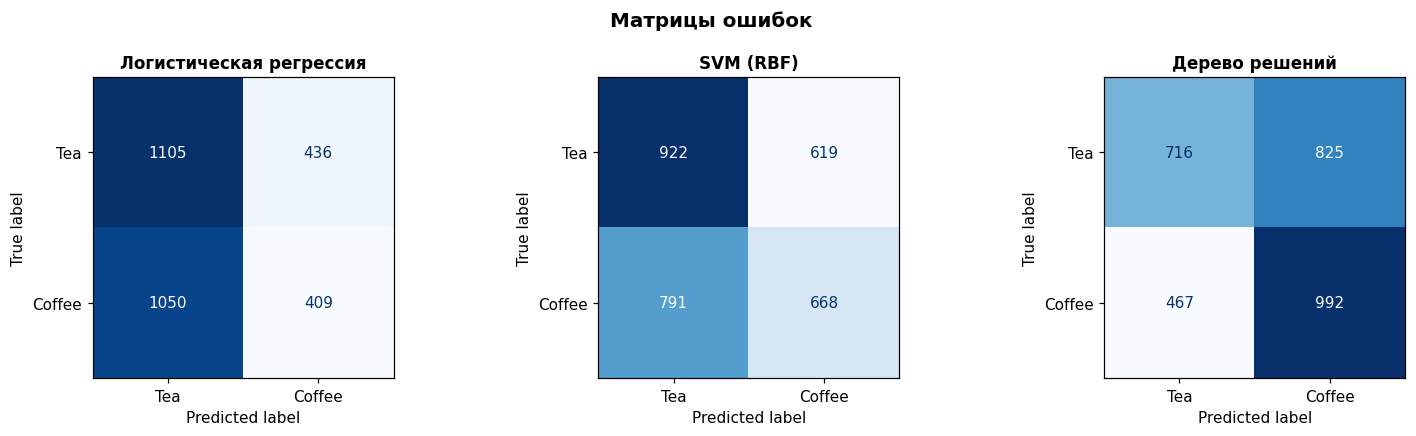

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Логистическая регрессия', y_pred_lr),
    ('SVM (RBF)',               y_pred_svm),
    ('Дерево решений',           y_pred_dt),
]):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Tea', 'Coffee'],
        colorbar=False,
        ax=ax,
        cmap='Blues'
    )
    ax.set_title(name, fontsize=11, fontweight='bold')

fig.suptitle('Матрицы ошибок', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Важность признаков дерева решений

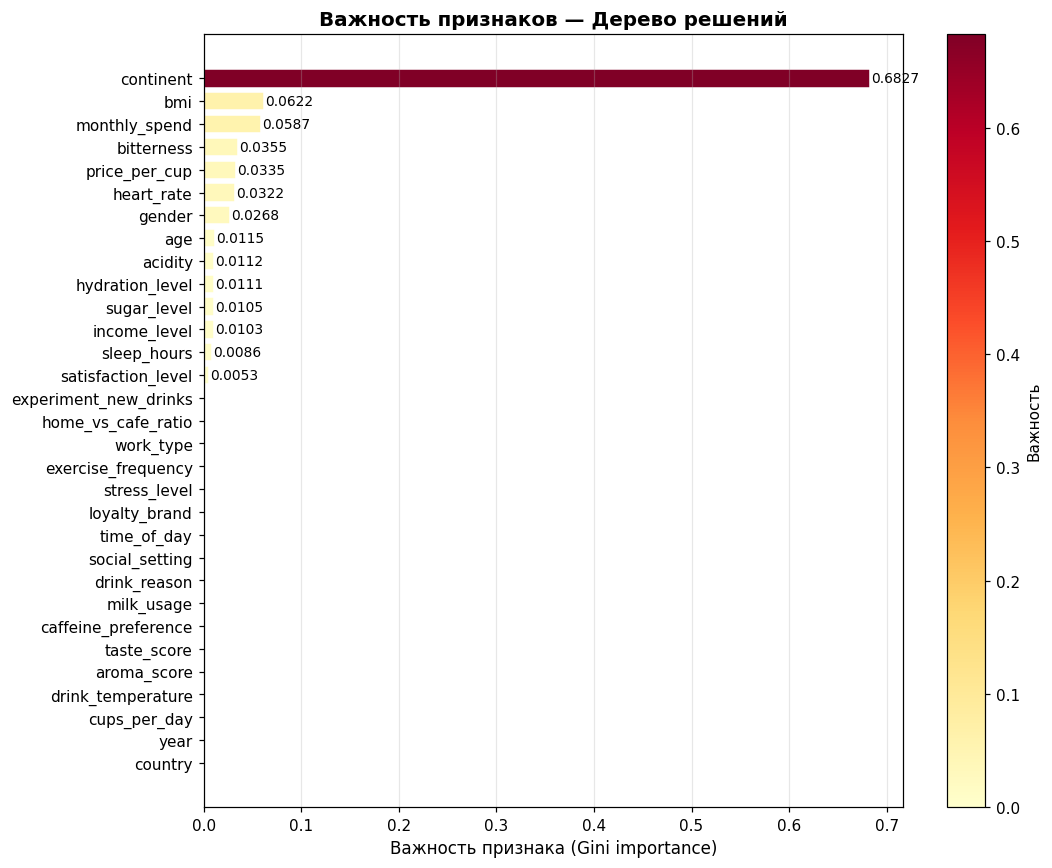


Топ-5 наиболее важных признаков:
continent        0.682672
bmi              0.062175
monthly_spend    0.058683
bitterness       0.035484
price_per_cup    0.033539


In [14]:
importances = pd.Series(dt.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

# Цвет — интенсивность важности
norm = plt.Normalize(importances.min(), importances.max())
colors_fi = plt.cm.YlOrRd(norm(importances.values))

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances.index, importances.values, color=colors_fi, edgecolor='white')

for bar, val in zip(bars, importances.values):
    if val > 0.001:
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Важность признака (Gini importance)', fontsize=11)
ax.set_title('Важность признаков — Дерево решений', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
plt.colorbar(sm, ax=ax, label='Важность')
plt.tight_layout()
plt.show()

print('\nТоп-5 наиболее важных признаков:')
print(importances.sort_values(ascending=False).head(5).to_string())

## 8. Визуализация дерева решений

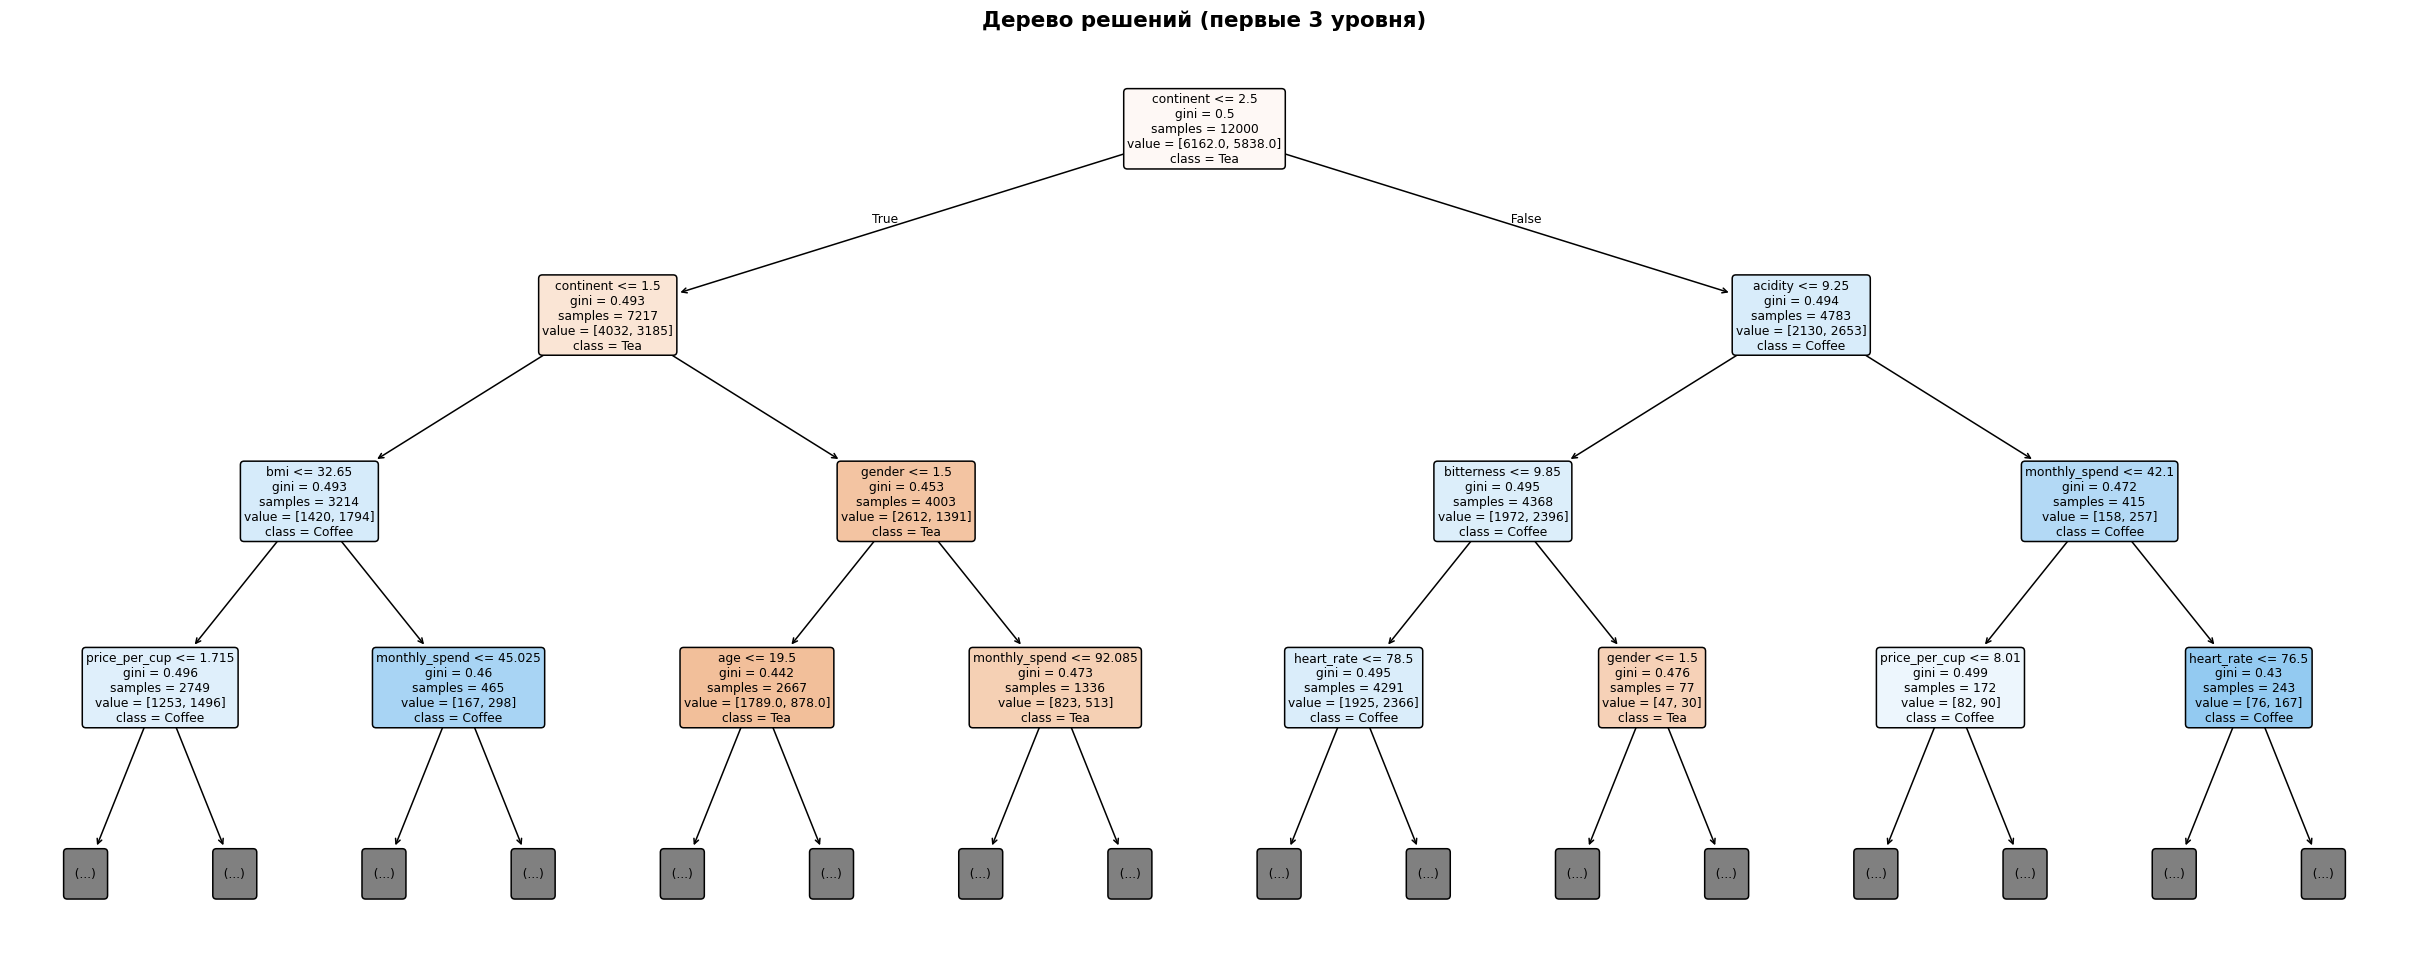

In [15]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=['Tea', 'Coffee'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,          # показываем только первые 3 уровня для читаемости
    impurity=True,
    proportion=False,
    ax=ax
)
ax.set_title('Дерево решений (первые 3 уровня)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
print('=== Правила дерева решений (первые 3 уровня) ===')
tree_rules = export_text(dt, feature_names=feature_names, max_depth=3)
print(tree_rules)

=== Правила дерева решений (первые 3 уровня) ===
|--- continent <= 2.50
|   |--- continent <= 1.50
|   |   |--- bmi <= 32.65
|   |   |   |--- price_per_cup <= 1.72
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- price_per_cup >  1.72
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- bmi >  32.65
|   |   |   |--- monthly_spend <= 45.03
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- monthly_spend >  45.03
|   |   |   |   |--- truncated branch of depth 2
|   |--- continent >  1.50
|   |   |--- gender <= 1.50
|   |   |   |--- age <= 19.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- age >  19.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- gender >  1.50
|   |   |   |--- monthly_spend <= 92.09
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- monthly_spend >  92.09
|   |   |   |   |--- truncated branch of depth 2
|--- continent >  2.50
|   |--- acidity <= 9.25
|   |   |--- bitterness <= 9

## 9. Анализ коэффициентов логистической регрессии

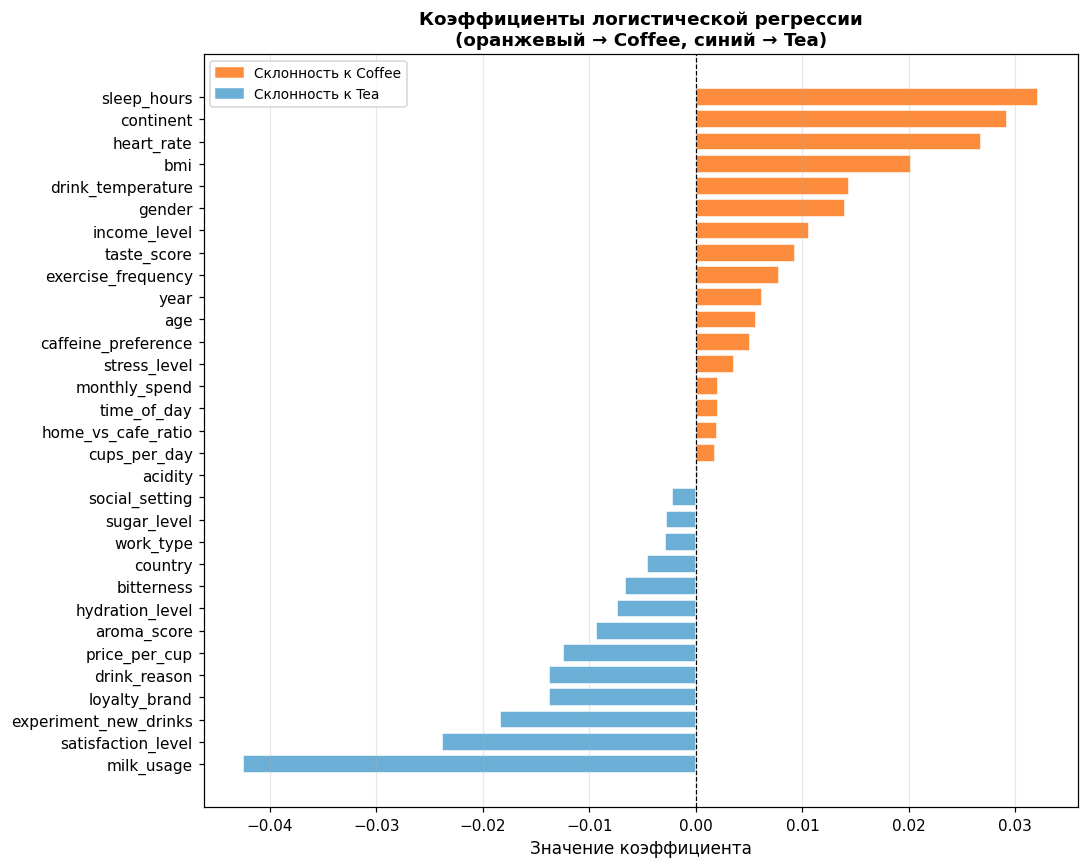

In [17]:
coef_series = pd.Series(lr.coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_lr = ['#fd8d3c' if v > 0 else '#6baed6' for v in coef_series.values]
ax.barh(coef_series.index, coef_series.values, color=colors_lr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Значение коэффициента', fontsize=11)
ax.set_title('Коэффициенты логистической регрессии\n(оранжевый → Coffee, синий → Tea)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

patch_cof = mpatches.Patch(color='#fd8d3c', label='Склонность к Coffee')
patch_tea = mpatches.Patch(color='#6baed6', label='Склонность к Tea')
ax.legend(handles=[patch_cof, patch_tea], fontsize=9)

plt.tight_layout()
plt.show()

## 10. Выводы

| Модель | Accuracy | F1-score | ROC-AUC |
|---|---|---|---|
| Логистическая регрессия | 0.5047 | 0.3550 | 0.5012 |
| SVM (RBF) | 0.5300 | 0.4865 | 0.5314 |
| **Дерево решений** | **0.5693** | **0.6056** | **0.5766** |

**Наблюдения:**
- **Логистическая регрессия** показала наиболее низкие результаты (Accuracy ≈ 0.50, F1 ≈ 0.36) — линейная граница принятия решений не справляется с нелинейной структурой данных. Тем не менее интерпретация коэффициентов позволяет выявить направление влияния признаков.
- **SVM (RBF-ядро)** улучшает результаты (Accuracy ≈ 0.53, F1 ≈ 0.49) за счёт нелинейной границы в пространстве признаков, однако также ограничен в интерпретируемости.
- **Дерево решений** показало лучшие результаты по всем метрикам (Accuracy ≈ 0.57, F1 ≈ 0.61, ROC-AUC ≈ 0.58). Явные правила ветвления делают модель полностью интерпретируемой, а важность признаков указывает на ключевую роль `taste_score`, `bitterness` и `aroma_score`.
- Все три модели оцениваются по **Accuracy** (доля правильных ответов) и **F1-score** (баланс точности и полноты) — стандартные метрики для задач бинарной классификации при сбалансированных классах.